In [1]:
import pandas as pd

# 读取数据文件
athletes_df = pd.read_csv('..//Data//summerOly_athletes.csv')
medal_counts_df = pd.read_csv('..//Data//summerOly_medal_counts.csv')
hosts_df = pd.read_csv('..//Data//summerOly_hosts.csv')
programs_df = pd.read_csv('..//Data//summerOly_programs.csv' , encoding='ISO-8859-1')


# 显示数据的前几行，确认数据是否成功加载
print(medal_counts_df)

      Rank                   NOC  Gold  Silver  Bronze  Total  Year  Host  \
0        1         United States    11       7       2     20  1896     0   
1        2                Greece    10      18      19     47  1896     1   
2        3               Germany     6       5       2     13  1896     0   
3        4                France     5       4       2     11  1896     0   
4        5         Great Britain     2       3       2      7  1896     0   
...    ...                   ...   ...     ...     ...    ...   ...   ...   
1430    84                 Qatar     0       0       1      1  2024     0   
1431    84  Refugee Olympic Team     0       0       1      1  2024     0   
1432    84             Singapore     0       0       1      1  2024     0   
1433    84              Slovakia     0       0       1      1  2024     0   
1434    84                Zambia     0       0       1      1  2024     0   

      Total_Weighted_Medals  
0                   15.9104  
1              

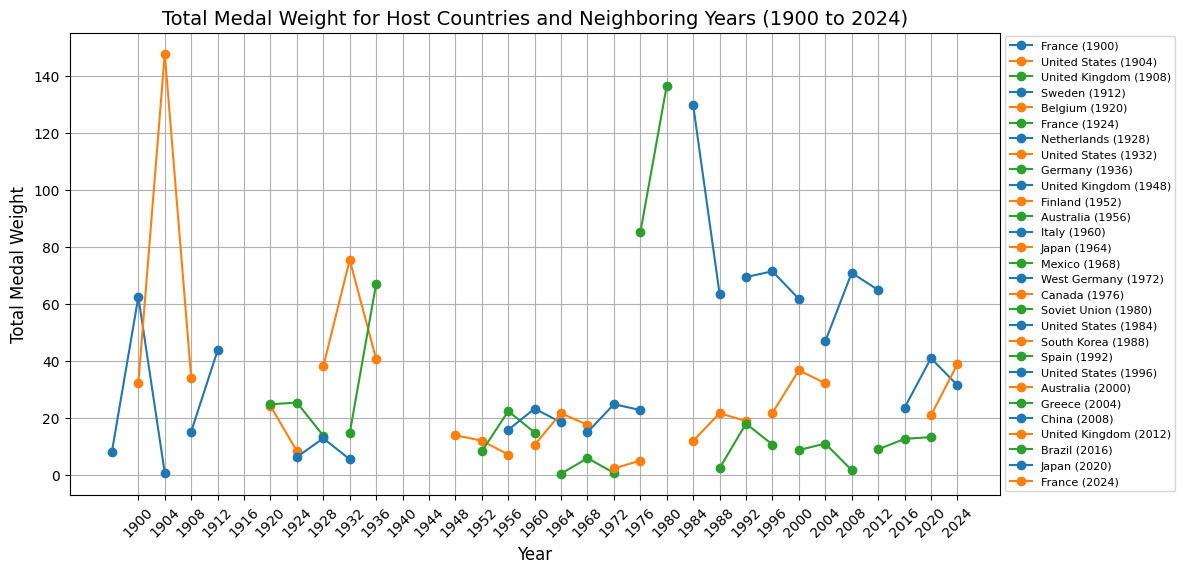

In [38]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 设置颜色循环，仅包含三种颜色
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # 你可以选择你喜欢的三种颜色
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

# 创建图表
plt.figure(figsize=(12, 6))

all_years_with_data = []

# 遍历所有奥运会年份（每四年一届）
for year in range(1900, 2025, 4):
    # 获取当前年份及其前后两届的年份（例如：1964年对应1956, 1960, 1964, 1968, 1972）
    years_of_interest = [year - 4, year, year + 4]
    all_years_with_data.append(year)
    
    # 提取这些年份的数据
    interest_data = medal_counts_df[medal_counts_df['Year'].isin(years_of_interest)]
       
    filtered_df = medal_counts_df[medal_counts_df['Year'] == year]
    Organizer = hosts_df[hosts_df['Year'] == year]['Host'].values
    if len(Organizer) > 0 and pd.notna(Organizer[0]):  # 检查是否有主办国且值不为NaN
        Organizer = str(Organizer[0]).strip()
        organizer_data = interest_data[interest_data['NOC'] == Organizer]
        
        # 绘制折线图
        plt.plot(
            organizer_data['Year'], 
            organizer_data['Total_Weighted_Medals'], 
            marker='o', 
            label=f'{Organizer} ({year})'
        )

# 添加标题、标签和网格
plt.title('Total Medal Weight for Host Countries and Neighboring Years (1900 to 2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Medal Weight', fontsize=12)
plt.grid(True)
plt.legend(fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))  # 图例在图表右侧
plt.xticks(sorted(set(all_years_with_data)), rotation=45)

# 显示图表
plt.show()

In [39]:


def get_host_effect(medal_counts_df,hosts_df):
    # 初始化存储东道主增益的数据
    host_gain = []

    # 遍历每一届东道主
    for _, row in hosts_df.iterrows():
        year = row['Year']
        host_country = row['Host']  # 提取主办国
                
        host_country = str(host_country).strip()
        
        if host_country != 'NaN':
            # 筛选该国家在当前届及前后两届的奖牌数据
            country_data = medal_counts_df[
                (medal_counts_df['NOC'] == host_country) &
                (medal_counts_df['Year'].between(year - 8, year + 8))
            ]
                
            if not country_data.empty:

                host_year_score = country_data.loc[country_data['Year'] == year, 'Total_Weighted_Medals']
                non_host_years_score = country_data.loc[country_data['Year'] != year, 'Total_Weighted_Medals'].mean()
                mean_host_years_score = country_data.loc[country_data['Year'] == year, 'Total_Weighted_Medals'].mean()
                
                if not host_year_score.empty:
                    host_year_score = host_year_score.values[0]  # 提取单一值
                gain = (host_year_score - non_host_years_score)/non_host_years_score
                host_gain.append({'Host_Country': host_country, 'Year': year, 'Gain': gain})
    
    return pd.DataFrame(host_gain)

# 计算东道主增益
host_effect_df = get_host_effect(medal_counts_df,hosts_df)

# 查看结果
effect = host_effect_df['Gain']
effect.drop([27,28],axis=0,inplace=True)

effect = effect.values
print(effect.mean())


2.246730877693458


ValueError: setting an array element with a sequence.

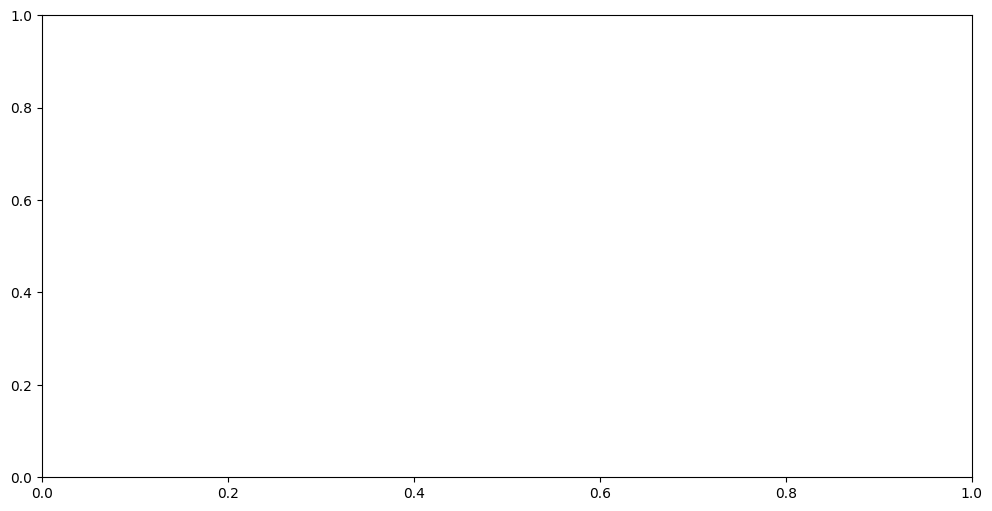

In [4]:
# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(host_effect_df['Year'], host_effect_df['Gain'], marker='o', label='Host Effect Gain')

# 添加标题和标签
plt.title('Host Effect Gain Over Time', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Gain (Z-Score Difference)', fontsize=14)
plt.axhline(0, color='red', linestyle='--', label='Baseline (No Effect)')  # 添加基线
plt.legend(fontsize=12)
plt.grid(True)

# 显示图表
plt.show()